In [40]:
import re

import matplotlib.pyplot as plt
import pandas as pd

# Read Logs

In [41]:
def read_logs_as_raw_string(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
            
            # This represents the data as a raw string format
            raw_content = r"{}".format(content)
            
            return raw_content
    except FileNotFoundError:
        return "Error: The file 'logs_maddpg.txt' was not found."

In [42]:
logs_maddpg_file_path = 'logs_maddpg/logs_maddpg.txt'
logs_maddpg = read_logs_as_raw_string(logs_maddpg_file_path)

In [43]:
logs_MAPS_file_path = 'logs_MAPS/logs_MAPS.txt' 
logs_our_method = read_logs_as_raw_string(logs_MAPS_file_path)

## Parse the logs

In [45]:
def parse_our_method(logs_our_method):
    pattern1 = re.compile(
            r"Episode (\d+).*?Result: (Success|Collision) \| Reward: ([\-?\d\.]+) \| Steps: (\d+)",
            re.DOTALL
        )
    episodes1 = [
        {
            'episode': int(m.group(1)),
            'result': m.group(2),
            'reward': float(m.group(3)),
            'steps': int(m.group(4))
        }
        for m in pattern1.finditer(logs_our_method)
    ]
    df = pd.DataFrame(episodes1)
    return df

In [46]:
def parse_maddpg_method(logs_maddpg_method):
    pattern2 = re.compile(
        r"Episode (\d+) ended with.*?\nINFO:src\.training\.episode_utils:Result: (Success|Collision) \| Reward: ([\-?\d\.]+) \| Steps: (\d+)"
    )
    episodes2 = [
        {
            'episode': int(m.group(1)),
            'result': m.group(2),
            'reward': float(m.group(3)),
            'steps': int(m.group(4))
        }
        for m in pattern2.finditer(logs_maddpg_method)
    ]
    df = pd.DataFrame(episodes2)
    return df

In [63]:
def parse_qmix_method(file_path):

    pattern = r"Episode (\d+) Result: (\w+) \| Reward: ([-\d.]+) \| Steps: (\d+)"
    
    data = []

    # Read the file
    with open(file_path, 'r') as f:
        for line in f:
            # Skip header lines or empty lines if present
            if not line.startswith("Episode"):
                continue
                
            match = re.search(pattern, line)
            if match:
                data.append({
                    "episode": int(match.group(1)),
                    "result": match.group(2),
                    "reward": float(match.group(3)),
                    "steps": int(match.group(4))
                })

    # Create DataFrame
    df = pd.DataFrame(data)
    return df

     episode     result  reward  steps
0          1    Timeout     1.0     40
1          2    Timeout     0.0     40
2          3    Timeout     0.0     40
3          4    Timeout     0.0     40
4          5    Timeout     0.0     40
..       ...        ...     ...    ...
995      996    Timeout     5.0     40
996      997    Timeout     1.0     40
997      998    Timeout    20.0     40
998      999    Timeout     8.0     40
999     1000  Collision     0.0      4

[1000 rows x 4 columns]


# Plot Comparison

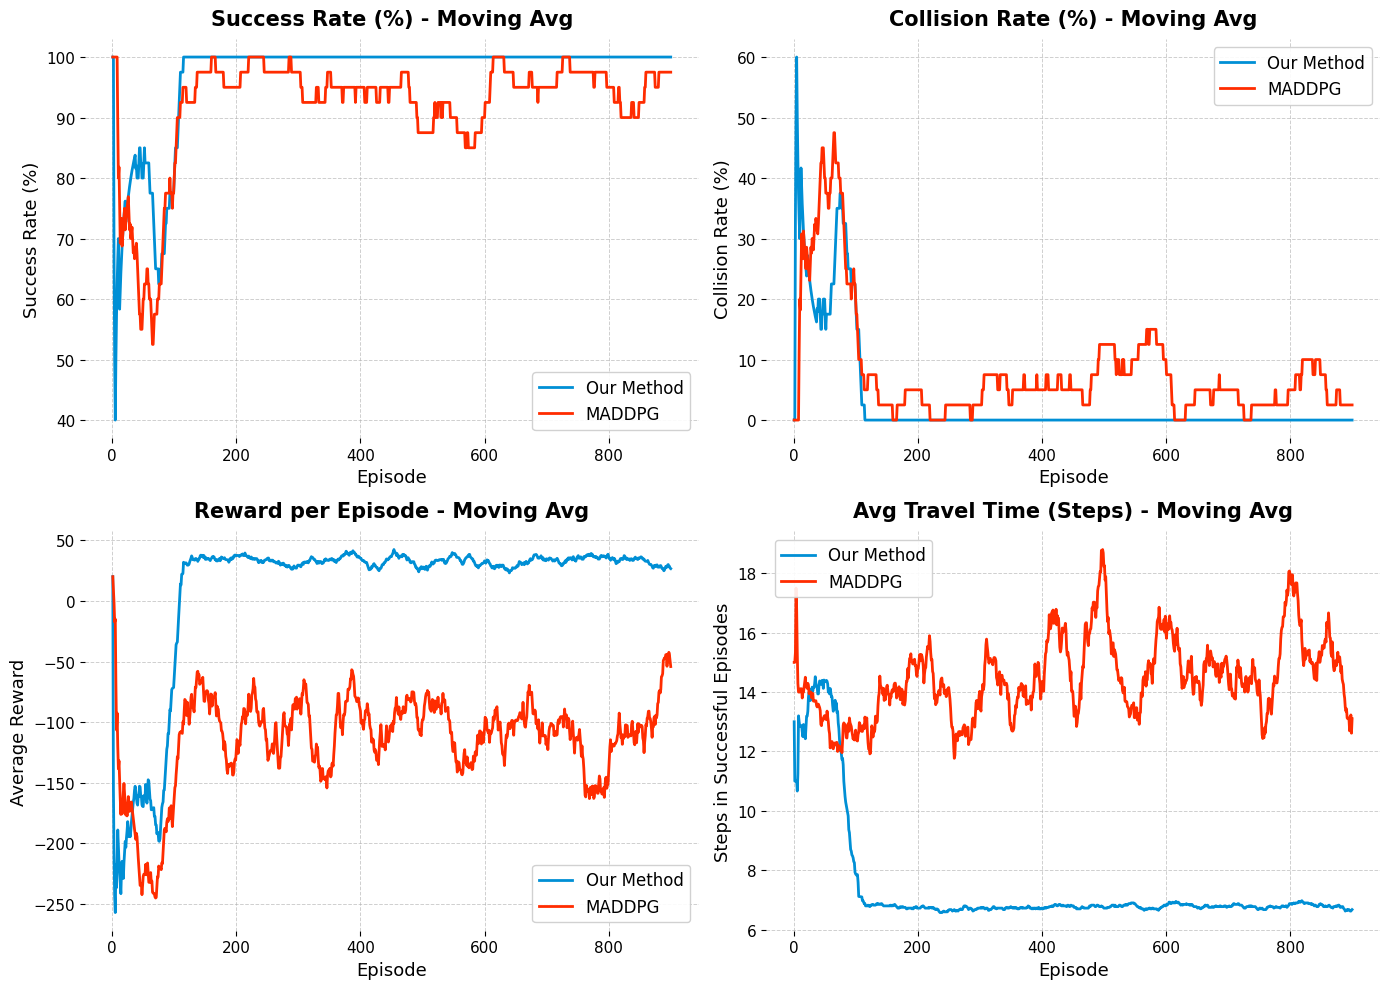

In [73]:
# --- 1. Metric Calculation Helpers ---
def calculate_success_rate(df: pd.DataFrame, window: int) -> pd.Series:
    """Calculates rolling success rate as a percentage."""
    return (df['result'] == 'Success').astype(int).rolling(window, min_periods=1).mean() * 100

def calculate_collision_rate(df: pd.DataFrame, window: int) -> pd.Series:
    """Calculates rolling collision rate as a percentage."""
    return (df['result'] == 'Collision').astype(int).rolling(window, min_periods=1).mean() * 100

def calculate_avg_reward(df: pd.DataFrame, window: int) -> pd.Series:
    """Calculates rolling average reward."""
    return df['reward'].rolling(window, min_periods=1).mean()

def calculate_travel_time(df: pd.DataFrame, window: int) -> pd.Series:
    """Calculates rolling average steps, considering only successful episodes."""
    success_mask = (df['result'] == 'Success')
    # Filter steps for successes, keeping original index (NaN for failures)
    successful_steps = df['steps'].where(success_mask) 
    return successful_steps.rolling(window, min_periods=1).mean()

# --- 2. Styling Helper ---
def apply_plot_style(ax, title, ylabel):
    """Applies consistent styling to a matplotlib axis."""
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Episode', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.legend(fontsize=12, frameon=True, facecolor='white', framealpha=0.9)

    # Clean up spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='major', labelsize=11)

# --- 3. Main Plotting Function ---
def plot_log_comparison(logs_our_method, logs_maddpg_method, window=20):
    """
    Parses logs and plots a 2x2 comparison grid of performance metrics.
    """
    # 1. Prepare Data
    # Assuming parse functions are defined globally or imported
    data_sources = [
        {
            'label': 'Our Method',
            'df': parse_our_method(logs_our_method),
            'color': '#008FD5'
        },
        {
            'label': 'MADDPG',
            'df': parse_maddpg_method(logs_maddpg_method),
            'color': '#FF2C00'
        }
    ]

    # 2. Define Metrics Configuration
    # Maps titles and labels to the specific calculation function
    metrics_config = [
        {
            'title': 'Success Rate (%) - Moving Avg',
            'ylabel': 'Success Rate (%)',
            'func': calculate_success_rate
        },
        {
            'title': 'Collision Rate (%) - Moving Avg',
            'ylabel': 'Collision Rate (%)',
            'func': calculate_collision_rate
        },
        {
            'title': 'Reward per Episode - Moving Avg',
            'ylabel': 'Average Reward',
            'func': calculate_avg_reward
        },
        {
            'title': 'Avg Travel Time (Steps) - Moving Avg',
            'ylabel': 'Steps in Successful Episodes',
            'func': calculate_travel_time
        }
    ]

    # 3. Setup Plot
    plt.style.use('default')
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    axs_flat = axs.flatten() # Flattens the 2x2 grid to a 1D array for easy iteration

    # 4. Plotting Loop
    for ax, metric in zip(axs_flat, metrics_config):

        # Plot each data source on the current axis
        for source in data_sources:
            df = source['df']

            # Calculate y-values using the specific metric function
            y_values = metric['func'](df, window)

            ax.plot(
                df['episode'], 
                y_values, 
                label=source['label'], 
                linewidth=2, 
                color=source['color']
            )

        # Apply styling to the current axis
        apply_plot_style(ax, metric['title'], metric['ylabel'])

    plt.tight_layout()
    plt.show()

plot_log_comparison(logs_our_method, logs_maddpg, window=40)

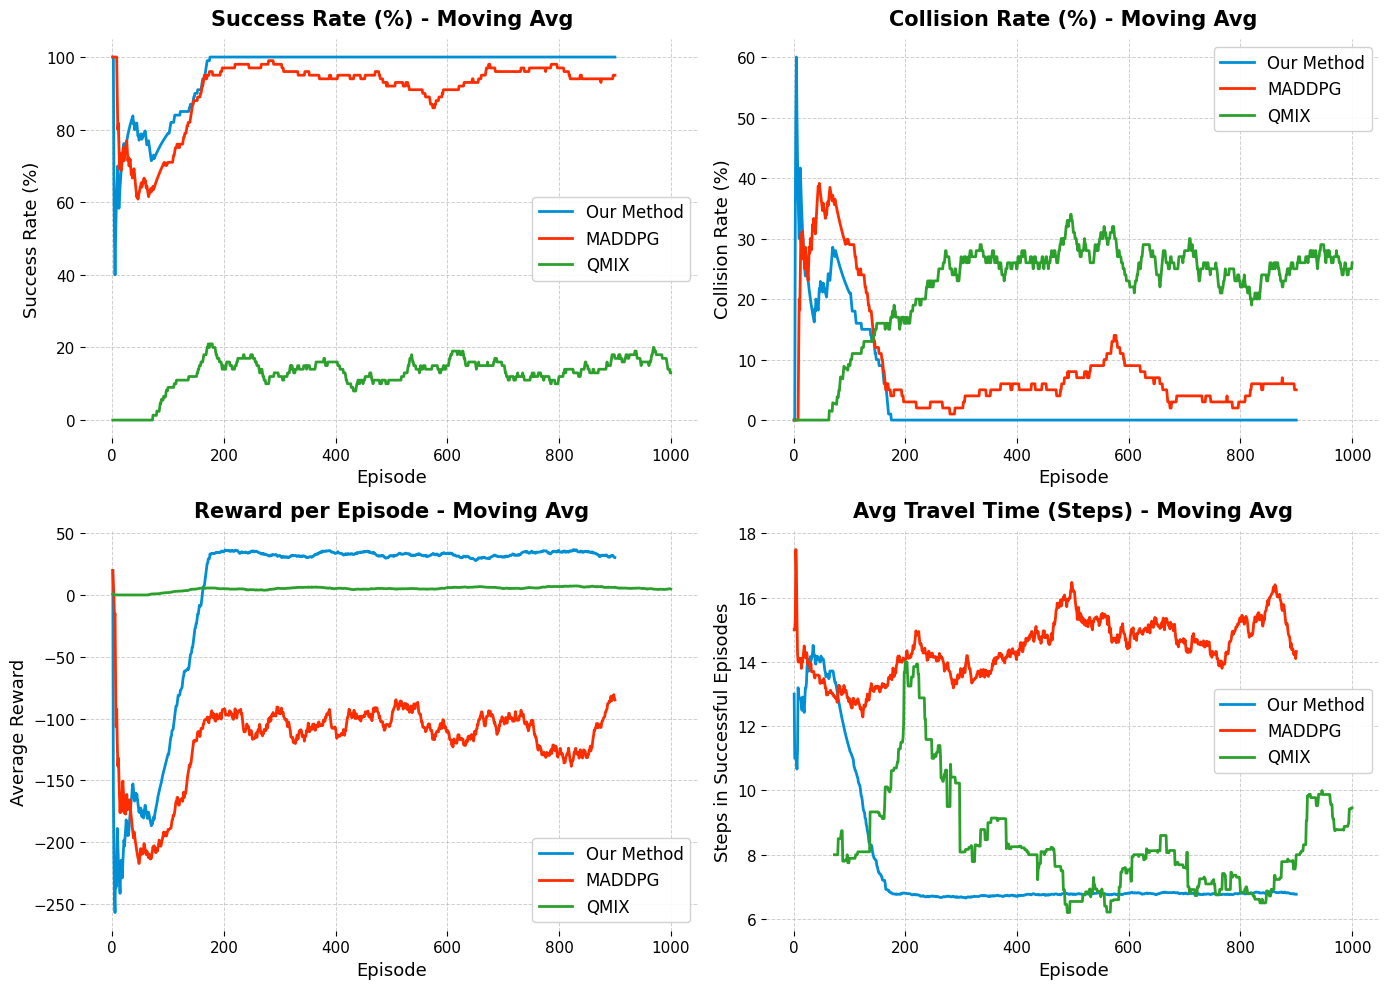

In [76]:
# --- 3. Main Plotting Function (Updated) ---
def plot_log_comparison(logs_our_method, logs_maddpg_method, logs_qmix_method, window=20):
    """
    Parses logs and plots a 2x2 comparison grid of performance metrics.
    Now supports 3 methods: Our Method, MADDPG, and QMIX.
    """
    # 1. Prepare Data
    # We assume parse_our_method, parse_maddpg_method, and parse_qmix_method are defined
    data_sources = [
        {
            'label': 'Our Method',
            'df': parse_our_method(logs_our_method),
            'color': '#008FD5' # Blue
        },
        {
            'label': 'MADDPG',
            'df': parse_maddpg_method(logs_maddpg_method),
            'color': '#FF2C00' # Red
        },
        {
            'label': 'QMIX',
            'df': parse_qmix_method(logs_qmix_method),
            'color': '#2CA02C' # Green
        }
    ]

    # 2. Define Metrics Configuration
    metrics_config = [
        {
            'title': 'Success Rate (%) - Moving Avg',
            'ylabel': 'Success Rate (%)',
            'func': calculate_success_rate
        },
        {
            'title': 'Collision Rate (%) - Moving Avg',
            'ylabel': 'Collision Rate (%)',
            'func': calculate_collision_rate
        },
        {
            'title': 'Reward per Episode - Moving Avg',
            'ylabel': 'Average Reward',
            'func': calculate_avg_reward
        },
        {
            'title': 'Avg Travel Time (Steps) - Moving Avg',
            'ylabel': 'Steps in Successful Episodes',
            'func': calculate_travel_time
        }
    ]

    # 3. Setup Plot
    plt.style.use('default')
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    axs_flat = axs.flatten()

    # 4. Plotting Loop
    for ax, metric in zip(axs_flat, metrics_config):
        
        # Plot each data source on the current axis
        for source in data_sources:
            df = source['df']
            
            # Calculate y-values using the specific metric function
            y_values = metric['func'](df, window)
            
            ax.plot(
                df['episode'], 
                y_values, 
                label=source['label'], 
                linewidth=2, 
                color=source['color']
            )
        
        # Apply styling to the current axis
        apply_plot_style(ax, metric['title'], metric['ylabel'])

    plt.tight_layout()
    plt.show()


plot_log_comparison(
    logs_our_method=logs_our_method,
    logs_maddpg_method=logs_maddpg,
    logs_qmix_method="results/qmixwd_20251213_194542/training_log.txt",
    window=100
)